# Итерационные методы решения СЛАУ

В данном разделе реализуем метод Якоби и метод Гаусса-Зейделя для нахождения решения СЛАУ итерационным способом.

В начале введём пару полезных функций, которые будут использоваться нами в дальнейшем:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Функция, которая будет выводить полезную информацию
def write_statistics(A, b, iter_x, iterations_amount, method, only_iter_and_eigenvals=False):

    # Раскладываем матрицу A на три верхнетреугольную, нижнетреугольную и диагональную
    L = np.tril(A, -1)
    D = np.diag(np.diag(A))
    U = np.triu(A, 1)

    if method == 1:
        method_name = "метод Якоби"
        B = -(np.linalg.inv(D)) @ (L + U)
    else:
        method_name = "метод Гаусса-Зейделя"
        B = -(np.linalg.inv(D + L)) @ U

    exact_x = np.linalg.solve(A, b)
    print("-----------------------------------")
    print(f"СТАТИСТИКА ({method_name}):")
    print("-----------------------------------\n")
    print("Количество итераций:", iterations_amount, end='\n\n')
    print("Максимальное по модулю собственное число матрицы B:", np.max(np.abs(np.linalg.eigvals(B))), end='\n\n')
    if not only_iter_and_eigenvals:
        print("Точное решение:", exact_x, end='\n\n')
        print("Итерационное решение", iter_x, end='\n\n')
        print("Разница итерационного и точного решений:", abs(exact_x - iter_x), end='\n\n')


# Построение графика зависимости невязки от каждой итерации
def discrepancy_vs_iteration(iterations, discrepancy, method):
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    label_name = "метод Якоби" if method == 1 else "метод Гаусса-Зейделя"
    
    # Первый график с логарифмической осью
    axs[0].plot(iterations, discrepancy, label=label_name, color="r")
    axs[0].scatter(iterations, discrepancy, label="Точные значения", color="r")
    axs[0].set_xlabel("Итерации")
    axs[0].set_ylabel("Невязка")
    axs[0].set_yscale("log")
    axs[0].set_title("График невязки (логарифм. шкала)")
    axs[0].legend()
    axs[0].grid()

    # Второй график без логарифмической оси
    axs[1].plot(iterations, discrepancy, label=label_name)
    axs[1].scatter(iterations, discrepancy, label="Точные значения")
    axs[1].set_xlabel("Итерации")
    axs[1].set_ylabel("Невязка")
    axs[1].set_title("График невязки (линейная шкала)")
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()


# построение графика нормы ошибки решения на каждой итерации
def x_k_vs_true_x(history, x_history, method):
    iterations = history[:-1, 0]
    x_final = x_history[-1]
    error_norms = np.linalg.norm(x_history[:-1] - x_final, axis=1)
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 строка, 2 столбца

    label_name = "метод Якоби" if method == 1 else "метод Гаусса-Зейделя"
    
    # Первый график с логарифмической осью
    axs[0].plot(iterations, error_norms, label=label_name, color="r")
    axs[0].scatter(iterations, error_norms, label="Точные значения", color="r")
    axs[0].set_xlabel("Итерации")
    axs[0].set_ylabel("Норма ошибки")
    axs[0].set_yscale("log")
    axs[0].set_title(r"График нормы ошибки решения $\|x^{(k)} - x^*\|_2$ (логарифм. шкала)")
    axs[0].legend()
    axs[0].grid()
    
    # Второй график без логарифмической оси
    axs[1].plot(iterations, error_norms, label=label_name)
    axs[1].scatter(iterations, error_norms, label="Точные значения")
    axs[1].set_xlabel("Итерации")
    axs[1].set_ylabel("Норма ошибки")
    axs[1].set_title(r"График нормы ошибки решения $\|x^{k} - x^*\|_2$")
    axs[1].legend()
    axs[1].grid()
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Для простоты назначим каждому алгоритму своё значение:
algos = {"Jacoby": 1,
         "Seidel": 0}

Отметим, что для каждого алгоритма критерием остановки будет $\|Ax^{(k)} - b\|_2 \le 10^{-8}$

## Метод Якоби

Суть метода: привести матрицу $A$ и вектор $b$ к матрице $B$ и вектору $c$, вычисляемым по формулам ниже:

\begin{align}
B &= -D^{-1}\cdot (L + U)\\
c &= D^{-1} \cdot b
\end{align}
Где $L + D + U = A$ - нижнетреугольная, диагональная и верхнетреугольная части матрицы $A$ соответственно.
Далее решение ищется методом ***простой итерации***.

Ниже приведён код реализации ***метода Якоби***:

In [3]:
import numpy as np


def jacoby_method(A, b, x0=None, max_iteration=1000, epsilon=10**-8):

    # Задаём начальное приближение
    if x0 is None:
        x = np.zeros(b.shape)
    else:
        x = x0.copy()

    
    disc = np.linalg.norm(A @ x - b) # Считаем невязку в самом начале

    # history - матрица, где в первом столбце - номер итерации, а
    # во втором - значение невязки на каждой итерации
    history = [np.array([0, disc])]

    # x_history - матрца, в строках которой записаны координаты решения на каждой итерации
    x_history = [x.copy()]

    # Разбиваем матрицу на нижне\верхне треугольную и диагональную
    # L + D + U = A
    D = np.diag(np.diag(A))
    L = np.tril(A, -1)
    U = np.triu(A, 1)

    # Согласно формулам, получаем матрицу B и вектор с
    B = -(np.linalg.inv(D)) @ (L + U)
    c = np.linalg.inv(D) @ b

    
    for iteration in range(1, max_iteration + 1):
        x = B @ x + c # Используем метод простой итерации
        disc = np.linalg.norm(A @ x - b)
        
        history.append(np.array([iteration, disc]))
        x_history.append(x.copy())
        
        if disc <= epsilon: # Проверяем критерий остановки
            return x, np.array(history), np.array(x_history), iteration

    # Если не хватило числа итераций для достижения нужной точности
    print("(Метод Якоби) Не достигнута сходимость за заданное количество итераций:", max_iteration)
    return x, np.array(history), np.array(x_history), max_iteration


### Несколько тестов (не входят в задание!)

Проведём пару тестов, чтобы убедиться в корректности работы алгоритма

#### Тест 1

-----------------------------------
СТАТИСТИКА (метод Якоби):
-----------------------------------

Количество итераций: 30

Максимальное по модулю собственное число матрицы B: 0.4999999999999999

Точное решение: [1.71428571 1.42857143 0.42857143]

Итерационное решение [1.71428571 1.42857143 0.42857143]

Разница итерационного и точного решений: [1.59655311e-09 1.33046085e-09 3.99138000e-10]



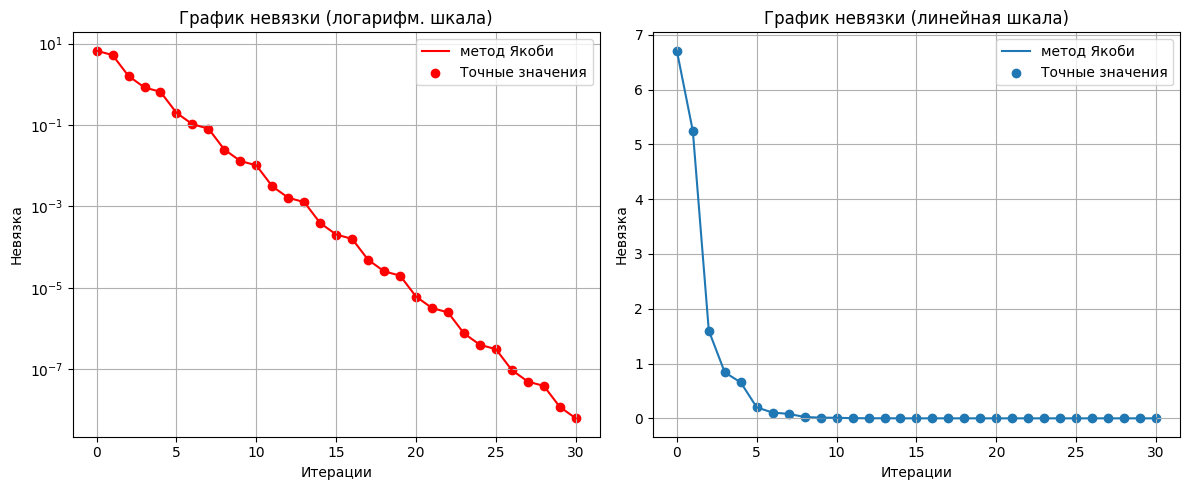

In [4]:
A = np.array([[2, -1, 0],
              [1,  2, 1],
              [1,  1, 2]])
 
b = np.array([2, 5, 4])

iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000) # Используем метод
write_statistics(A, b, iter_x, iterations_amount, method=algos["Jacoby"]) # Выводим статистику
discrepancy_vs_iteration(history[:, 0], history[:, 1], method=algos["Jacoby"]) # Строим графики невязки

#### Тест 2

-----------------------------------
СТАТИСТИКА (метод Якоби):
-----------------------------------

Количество итераций: 9

Максимальное по модулю собственное число матрицы B: 0.03250526521058293

Точное решение: [0.02180498 0.05335004 1.01019615 0.05819688 2.66237518]

Итерационное решение [0.02180498 0.05335004 1.01019615 0.05819688 2.66237518]

Разница итерационного и точного решений: [4.33611480e-14 5.87585536e-14 1.31006317e-14 1.13228871e-13
 1.37667655e-14]



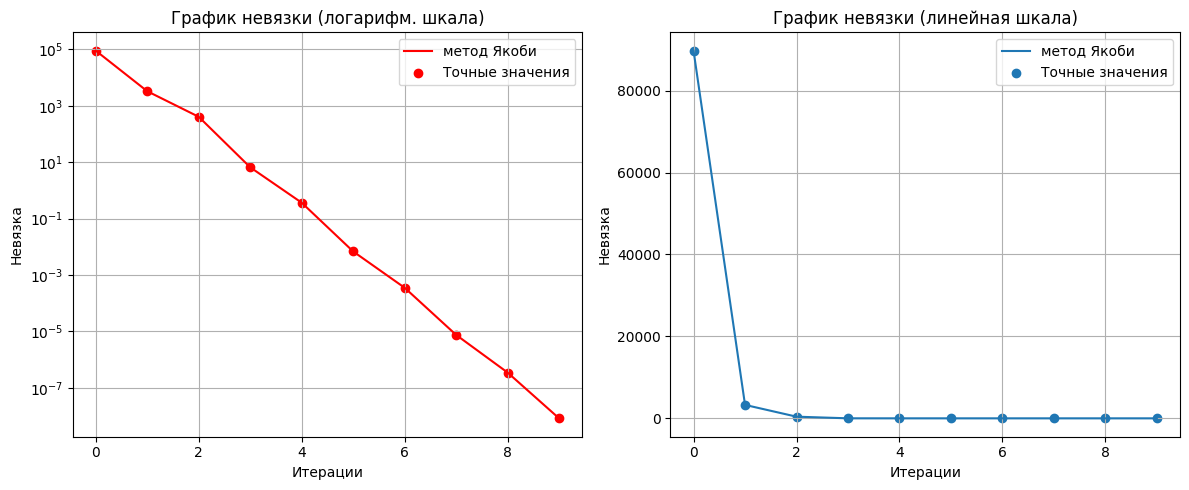

In [5]:
A = np.array([[100052, -21, 30, 715, 22],
              [112, 42431 , 402, 270, 998],
              [95,  11, 32154, 32, 241],
              [14,  5544, 21, 54542, 31],
              [54,  238, 217, 9, 31134]])

b = np.array([2311, 5345, 33128, 3574, 83124])

iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000) # Используем метод
write_statistics(A, b, iter_x, iterations_amount, method=algos["Jacoby"]) # Выводим статистику
discrepancy_vs_iteration(history[:, 0], history[:, 1], method=algos["Jacoby"]) # Строим графики невязки

## Метод Гаусса-Зейделя

По сути является модификацией метода Якоби. Идея заключается в том, чтобы "не лениться" и использовать уже посчитанные значения в подсчёте следующих значений. Формулы для матрицы B и c выглядят следующим образом:

\begin{align}
B &= -(D + L)^{-1} U\\
c &= (D + L)^{-1} b
\end{align}

Основная фомула:
\begin{align}
x_i^{(k+1)} = \frac{1}{a_{ii}} \left( b_i - \sum_{j=1}^{i-1} a_{ij} x_j^{(k+1)} - \sum_{j=i+1}^{n} a_{ij} x_j^{(k)} \right)
\end{align}

Где $L + D + U = A$ - нижнетреугольная, диагональная и верхнетреугольная части матрицы $A$ соответственно.

Ниже приведён код реализации ***метода Гаусса-Зейделя***:

In [6]:
import numpy as np


def gauss_seidel_method(A, b, x0=None, max_iteration=1000, epsilon=10**-8):

    # Реализцаия до основного цикла такая же, что и в методе Якоби
    if x0 is None:
        x = np.zeros(b.shape)
    else:
        x = x0.copy()

    disc = np.linalg.norm(A @ x - b)
    history = [np.array([0, disc])]
    x_history = [x.copy()]

    D = np.diag(np.diag(A))
    L = np.tril(A, -1)
    U = np.triu(A, 1)

    B = -(np.linalg.inv(D + L)) @ U
    c = np.linalg.inv(D + L) @ b

    for iteration in range(1, max_iteration + 1):
        x_new = x.copy() # Работаем с копией вектора
        for i in range(A.shape[0]):
            sum_before_i = np.dot(A[i, :i], x_new[:i])  # до i считаем, учитывая обновлённые значения
            sum_after_i = np.dot(A[i, i + 1:], x[i + 1:])  # после i считаем, со старыми значениями
            x_new[i] = (b[i] - sum_before_i - sum_after_i) / A[i, i] # i-ая новая координата по формуле.
            
        disc = np.linalg.norm(A @ x_new - b)
        history.append(np.array([iteration, disc]))
        x_history.append(x_new.copy())
        
        if disc <= epsilon:
            return x, np.array(history), np.array(x_history), iteration
        x = x_new

    print("(Метод Гаусса-Зейделя) Не достигнута сходимость за заданное количество итераций:", max_iteration)
    return x, np.array(history), np.array(x_history), max_iteration


### Несколько тестов (не входят в задание!)

Проведём те же тесты, что и для метода Якоби

#### Тест 1

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 20

Максимальное по модулю собственное число матрицы B: 0.3535533905932738

Точное решение: [1.71428571 1.42857143 0.42857143]

Итерационное решение [1.71428571 1.42857143 0.42857143]

Разница итерационного и точного решений: [5.32184341e-09 4.25747460e-09 5.32184574e-10]



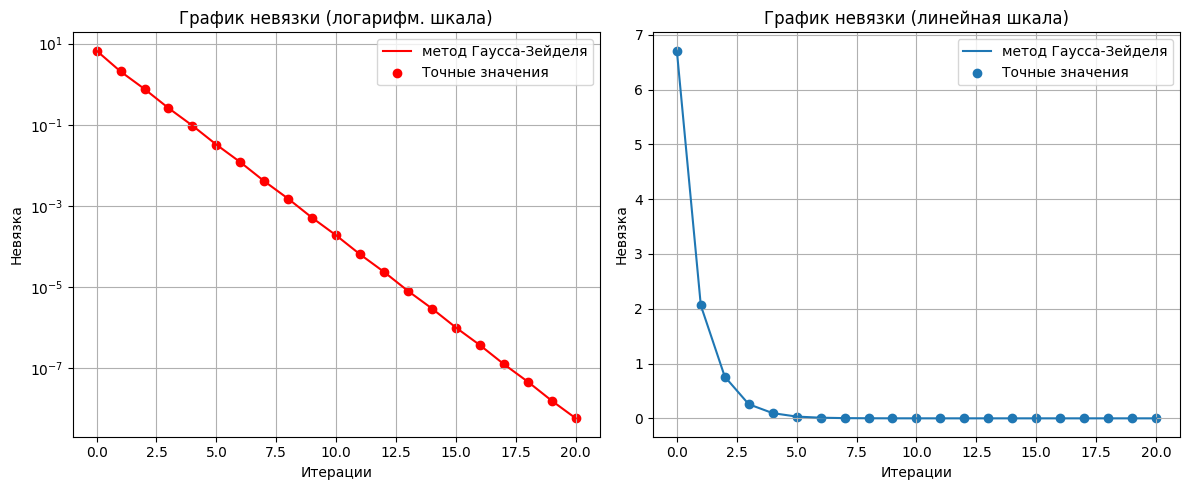

In [7]:
A = np.array([[2, -1, 0],
              [1,  2, 1],
              [1,  1, 2]])
 
b = np.array([2, 5, 4])

iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000) # Используем метод
write_statistics(A, b, iter_x, iterations_amount, method=algos["Seidel"]) # Выводим статистику
discrepancy_vs_iteration(history[:, 0], history[:, 1], method=algos["Seidel"]) # Строим графики невязки

#### Тест 2

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 6

Максимальное по модулю собственное число матрицы B: 0.0012412701327945796

Точное решение: [0.02180498 0.05335004 1.01019615 0.05819688 2.66237518]

Итерационное решение [0.02180498 0.05335004 1.01019615 0.05819688 2.66237518]

Разница итерационного и точного решений: [2.65447386e-14 3.38014339e-13 2.22044605e-15 3.46597751e-14
 2.66453526e-15]



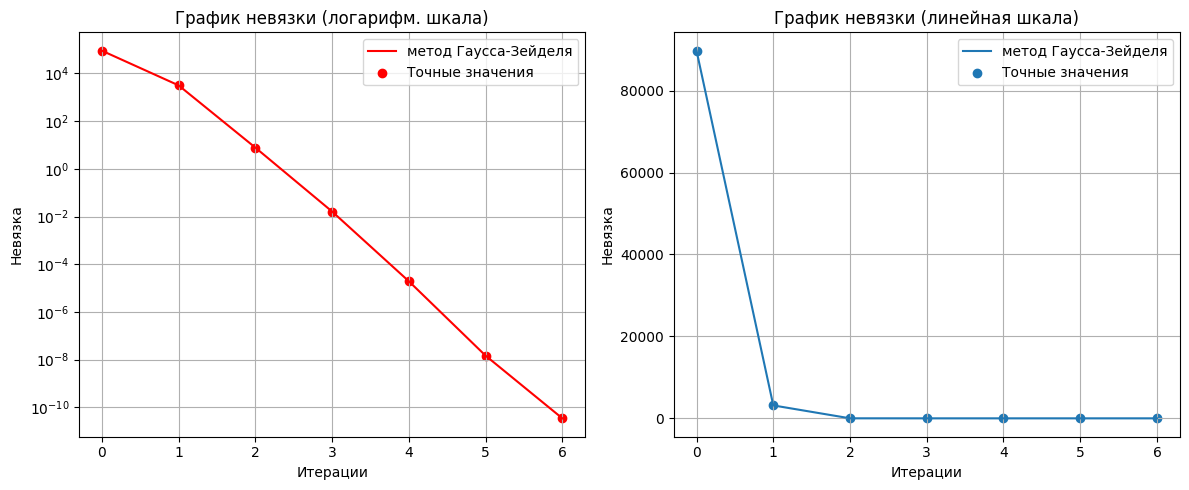

In [8]:
A = np.array([[100052, -21, 30, 715, 22],
              [112, 42431 , 402, 270, 998],
              [95,  11, 32154, 32, 241],
              [14,  5544, 21, 54542, 31],
              [54,  238, 217, 9, 31134]])

b = np.array([2311, 5345, 33128, 3574, 83124])

iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000) # Используем метод
write_statistics(A, b, iter_x, iterations_amount, method=algos["Seidel"]) # Выводим статистику
discrepancy_vs_iteration(history[:, 0], history[:, 1], method=algos["Seidel"]) # Строим графики невязки

## 2. Исследование скорости сходимости от размера системы

Для диагонально преобладающей матрицы из предыдущего раздела, используя оба метода, исследуем
зависимость скорости сходимости от размера системы и построим графики невязки $\|Ax_k - b\|_2$:

**(a)** Сравним число итераций до достижения заданной точности.

**(b)** Уменьшим диагональные элементы в 2 раза и пронаблюдаем изменение характера сходимости.

**(c)** Для положительно определённой матрицы $A = B^TB + \alpha I$ при $n = 500$.

### (a) Сравним число итераций до достижения заданной точности.

Матрица A:
 [[ 1.48058120e+01  9.01428613e-01  4.63987884e-01  1.97316968e-01
  -6.87962719e-01 -6.88010959e-01 -8.83832776e-01  7.32352292e-01]
 [ 2.02230023e-01  1.50267740e+01 -9.58831011e-01  9.39819704e-01
   6.64885282e-01 -5.75321779e-01 -6.36350066e-01 -6.33190980e-01]
 [-3.91515514e-01  4.95128633e-02  1.26223851e+01 -4.17541720e-01
   2.23705789e-01 -7.21012279e-01 -4.15710703e-01 -2.67276313e-01]
 [-8.78600316e-02  5.70351923e-01 -6.00652436e-01  1.32533030e+01
   1.84829138e-01 -9.07099175e-01  2.15089704e-01 -6.58951753e-01]
 [-8.69896814e-01  8.97771075e-01  9.31264066e-01  6.16794696e-01
   1.49993160e+01 -8.04655772e-01  3.68466053e-01 -1.19695013e-01]
 [-7.55923530e-01 -9.64617978e-03 -9.31222958e-01  8.18640804e-01
  -4.82440037e-01  1.37396320e+01 -3.76577848e-01  4.01360424e-02]
 [ 9.34205587e-02 -6.30291089e-01  9.39169256e-01  5.50265647e-01
   8.78997883e-01  7.89654701e-01  1.49213476e+01  8.43748470e-01]
 [-8.23014996e-01 -6.08034275e-01 -9.09545422e-01 -3.4933

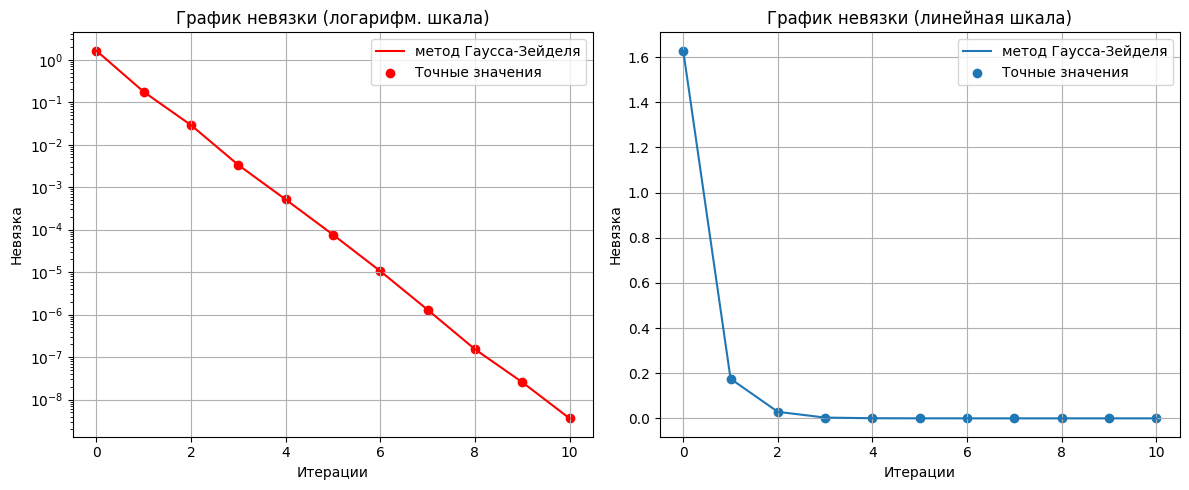

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 7

Максимальное по модулю собственное число матрицы B: 0.03380665006030916

Точное решение: [0.0202962  0.03837196 0.01972555 0.06503486 0.00286214 0.07169632
 0.0445252  0.0198103 ]

Итерационное решение [0.0202962  0.03837196 0.01972555 0.06503486 0.00286214 0.07169632
 0.0445252  0.0198103 ]

Разница итерационного и точного решений: [7.27862388e-10 1.56543105e-10 3.64018458e-10 3.97932437e-10
 1.65002799e-10 4.51172572e-11 1.20838811e-10 4.31749775e-12]



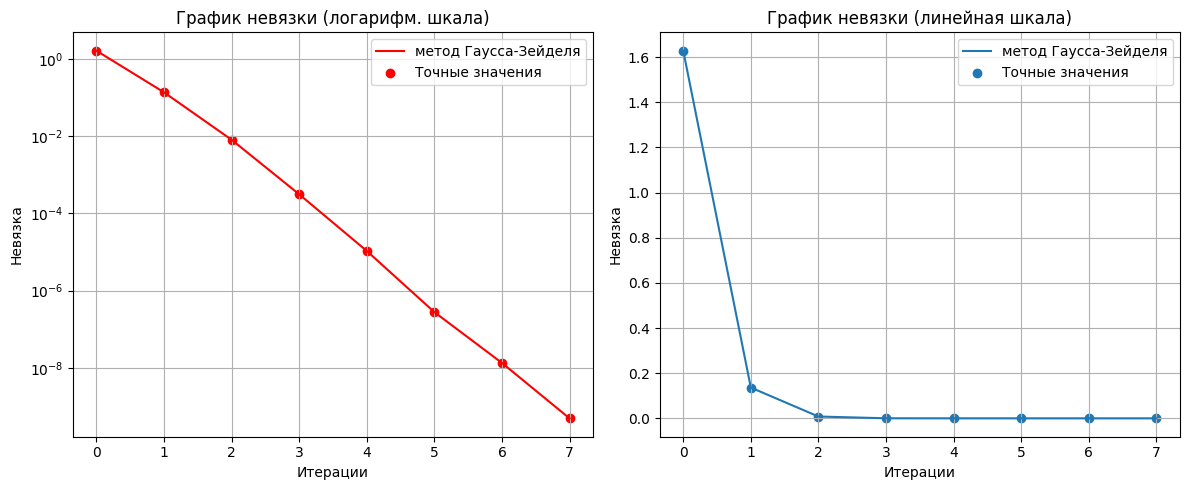

In [9]:
# В целом норм, но можно изменить этот блок, когда начнём объединять всё
np.random.seed(42)  # Для воспроизводимости результатов
n = 8

# Создаем случайную матрицу
A = np.random.rand(n, n) * 2 - 1
# Делаем матрицу диагонально преобладающей для устойчивости
for i in range(n):
    A[i, i] = np.sum(np.abs(A[i, :])) + 10

# создаём случайный вектор
b = np.random.rand(n)
print("Матрица A:\n", A, end='\n\n')
print("Вектор b:\n", b, end='\n\n')

# Применяем метод Якоби
iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000)

# Cтатистика и графики невязки
write_statistics(A, b, iter_x, iterations_amount, method='метод Якоби')
discrepancy_vs_iteration(history[:, 0], history[:, 1], 'метод Якоби')


# Применяем метод Гаусса-Зейделя
iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000)

# Статистика и графики невязки
write_statistics(A, b, iter_x, iterations_amount, 'метод Гаусса-Зейделя')
discrepancy_vs_iteration(history[:, 0], history[:, 1], 'метод Гаусса-Зейделя')

### (b) Уменьшим диагональные элементы в 2 раза и пронаблюдаем изменение характера сходимости.

Матрица A:
 [[ 7.40290599  0.90142861  0.46398788  0.19731697 -0.68796272 -0.68801096
  -0.88383278  0.73235229]
 [ 0.20223002  7.513387   -0.95883101  0.9398197   0.66488528 -0.57532178
  -0.63635007 -0.63319098]
 [-0.39151551  0.04951286  6.31119257 -0.41754172  0.22370579 -0.72101228
  -0.4157107  -0.26727631]
 [-0.08786003  0.57035192 -0.60065244  6.62665152  0.18482914 -0.90709917
   0.2150897  -0.65895175]
 [-0.86989681  0.89777107  0.93126407  0.6167947   7.49965798 -0.80465577
   0.36846605 -0.11969501]
 [-0.75592353 -0.00964618 -0.93122296  0.8186408  -0.48244004  6.86981598
  -0.37657785  0.04013604]
 [ 0.09342056 -0.63029109  0.93916926  0.55026565  0.87899788  0.7896547
   7.46067378  0.84374847]
 [-0.823015   -0.60803428 -0.90954542 -0.34933934 -0.22264542 -0.45730194
   0.65747502  7.15692488]]

Вектор b:
 [0.28093451 0.54269608 0.14092422 0.80219698 0.07455064 0.98688694
 0.77224477 0.19871568]

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----

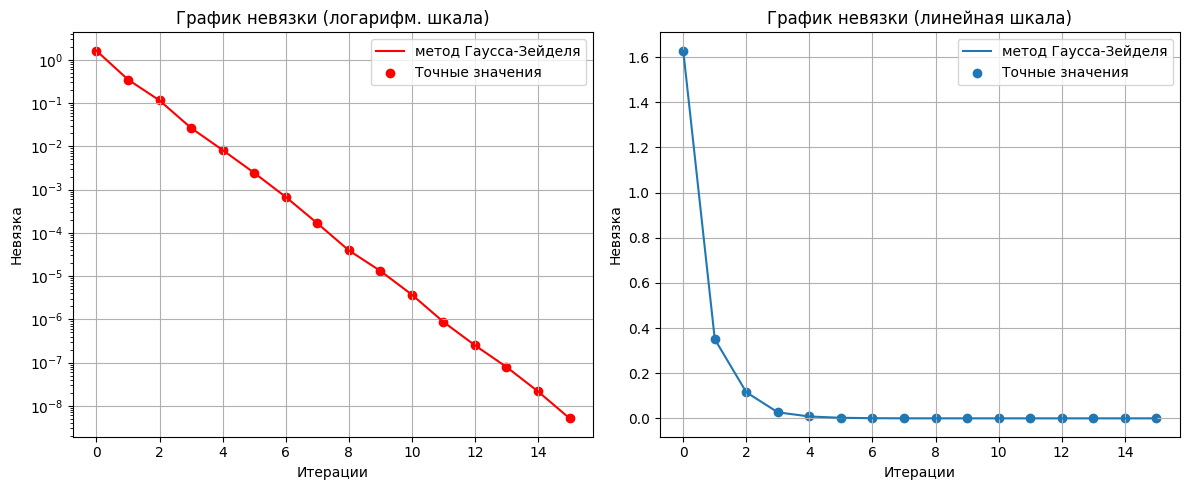

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 9

Максимальное по модулю собственное число матрицы B: 0.10134986346905829

Точное решение: [ 0.0366026   0.08243786  0.05670121  0.14228675 -0.00180611  0.14198492
  0.07127987  0.05559748]

Итерационное решение [ 0.03660259  0.08243786  0.05670121  0.14228676 -0.00180611  0.14198492
  0.07127987  0.05559748]

Разница итерационного и точного решений: [3.52998848e-09 1.61418873e-09 2.12133421e-09 3.06910170e-09
 6.76588147e-10 5.25627014e-10 1.63460454e-09 2.88229537e-10]



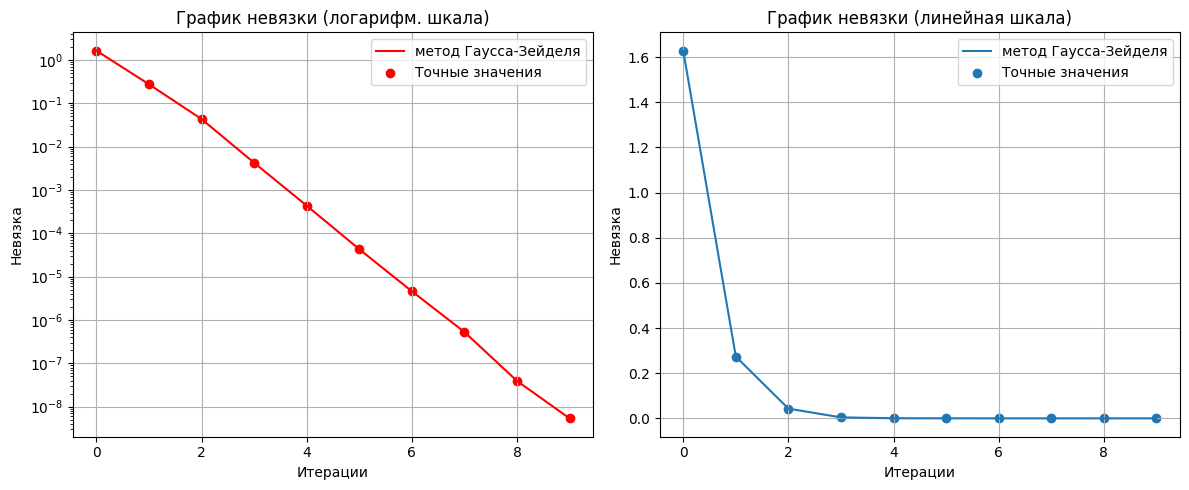

In [10]:
# Создаем случайную матрицу
np.random.seed(42)  # Для воспроизводимости результатов
n = 8
A = np.random.rand(n, n) * 2 - 1

# Делаем матрицу диагонально преобладающей для устойчивости
for i in range(n):
    A[i, i] = np.sum(np.abs(A[i, :])) + 10

# создаём случайный вектор
b = np.random.rand(n)
np.fill_diagonal(A, np.diag(A) * 0.5) # Собственно, само уменьшение диагональных элементов
print("Матрица A:\n", A, end='\n\n')
print("Вектор b:\n", b, end='\n\n')


# Применяем метод Якоби
iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000)

# Cтатистика и графики невязки
write_statistics(A, b, iter_x, iterations_amount, method='метод Якоби')
discrepancy_vs_iteration(history[:, 0], history[:, 1], 'метод Якоби')


# Применяем метод Гаусса-Зейделя
iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000)

# Статистика и графики невязки
write_statistics(A, b, iter_x, iterations_amount, 'метод Гаусса-Зейделя')
discrepancy_vs_iteration(history[:, 0], history[:, 1], 'метод Гаусса-Зейделя')

Как мы можем наблюдать, необходимое количество итераций в обоих методах увеличилось, после уменьшения диагональных элементов. 

### (c) Сходимость для положительно определённой матрицы $A = B^TB + \alpha I$ при $n = 500$.

In [11]:
# В целом норм, но можно изменить этот блок, когда начнём объединять всё
n = 500
B = np.random.randn(n, n)
A = B.T @ B + 0.1 * np.eye(n)
for i in range(n):
    row_sum = np.sum(np.abs(A[i])) - np.abs(A[i, i])
    A[i, i] = row_sum + 0.0001

b = np.random.rand(n)

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 11

Максимальное по модулю собственное число матрицы B: 0.028241555544130437



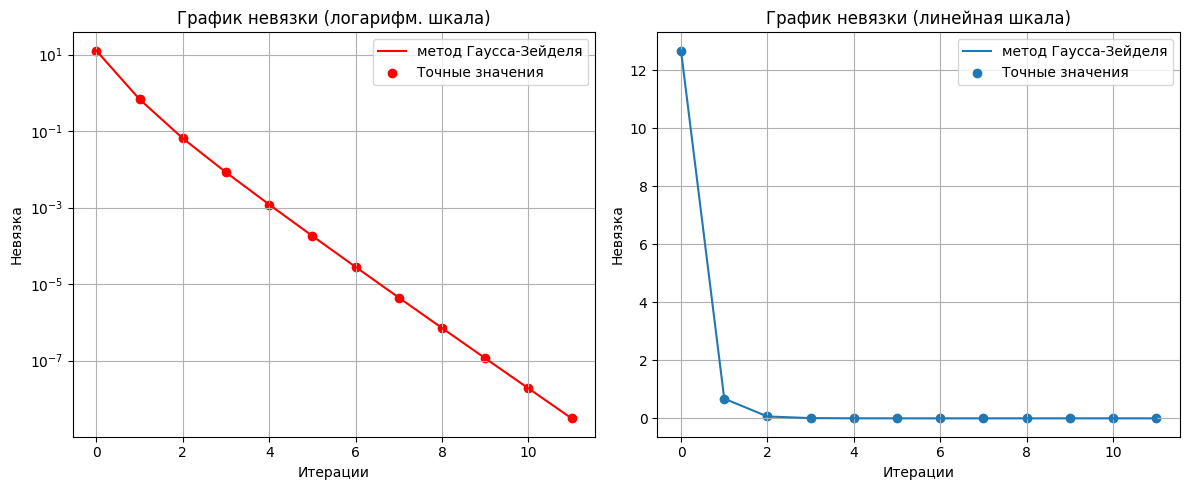

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 6

Максимальное по модулю собственное число матрицы B: 0.028241555544130437



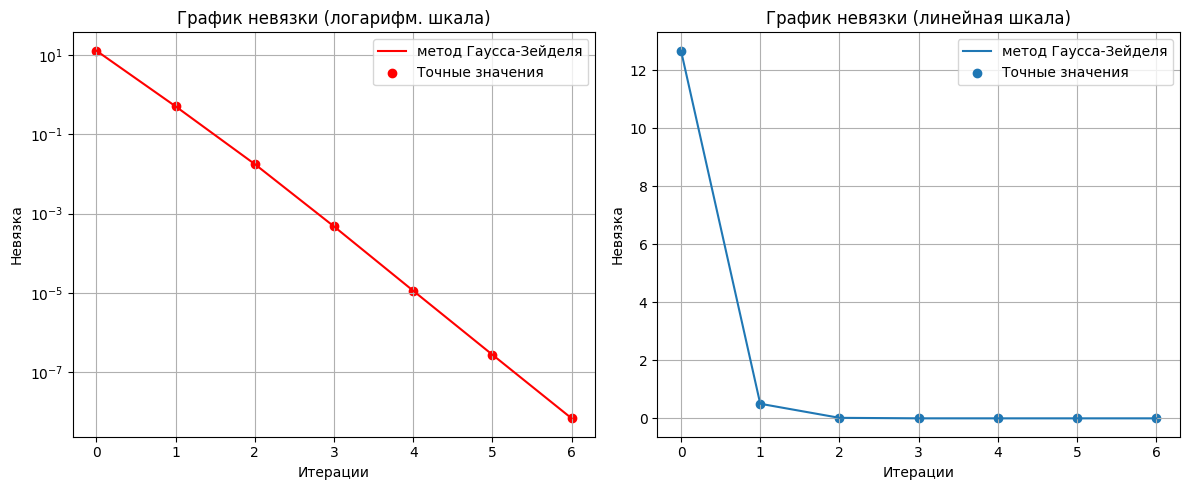

In [12]:
# Применяем метод Якоби
iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000)

# Cтатистика и графики невязки
write_statistics(A, b, iter_x, iterations_amount, method='метод Якоби', only_iter_and_eigenvals=True)
discrepancy_vs_iteration(history[:, 0], history[:, 1], 'метод Якоби')


# Применяем метод Гаусса-Зейделя
iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000)

# Статистика и графики невязки
write_statistics(A, b, iter_x, iterations_amount, 'метод Гаусса-Зейделя', only_iter_and_eigenvals=True)
discrepancy_vs_iteration(history[:, 0], history[:, 1], 'метод Гаусса-Зейделя')

## 3. Исследование влияния начального приближения $x^{(0)}$

Исследуем влияние начально приближения и построим графики зависимости евклидовой нормы ошибки $\|x^{k} - x^*\|_2$ от $k$:

**(a)** $x^{(0)}$ = 0

**(b)** $x^{(0)}$ - случайный вектор, $\|x^{(0)}\|_2$ = 1

**(c)** $x^{(0)}$ близок к точному решению $x^{*}$.

### (a) Начальное приближение $x^{(0)}$ = 0.

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 24

Максимальное по модулю собственное число матрицы B: 0.0928487357093806



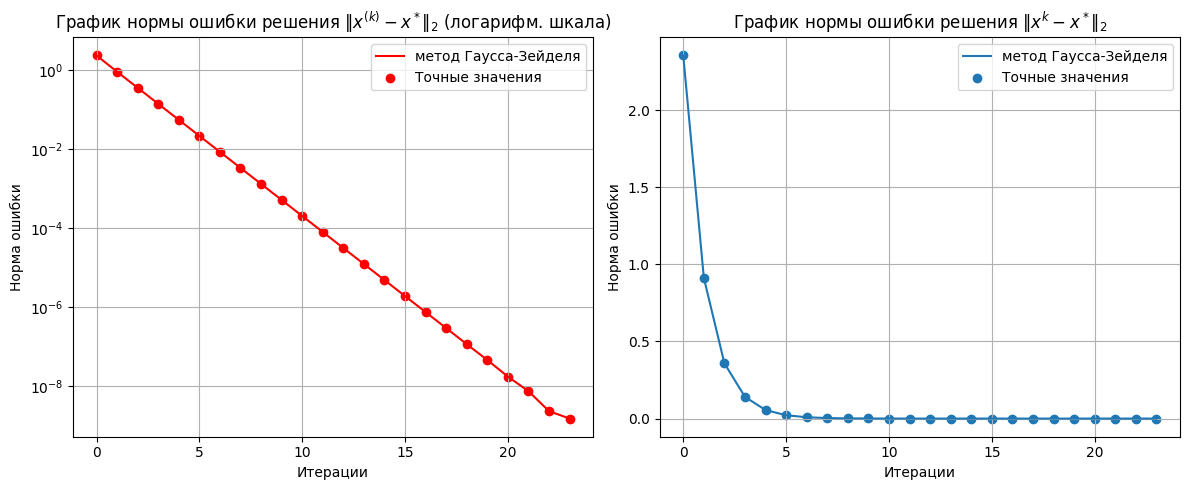

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 9

Максимальное по модулю собственное число матрицы B: 0.0928487357093806



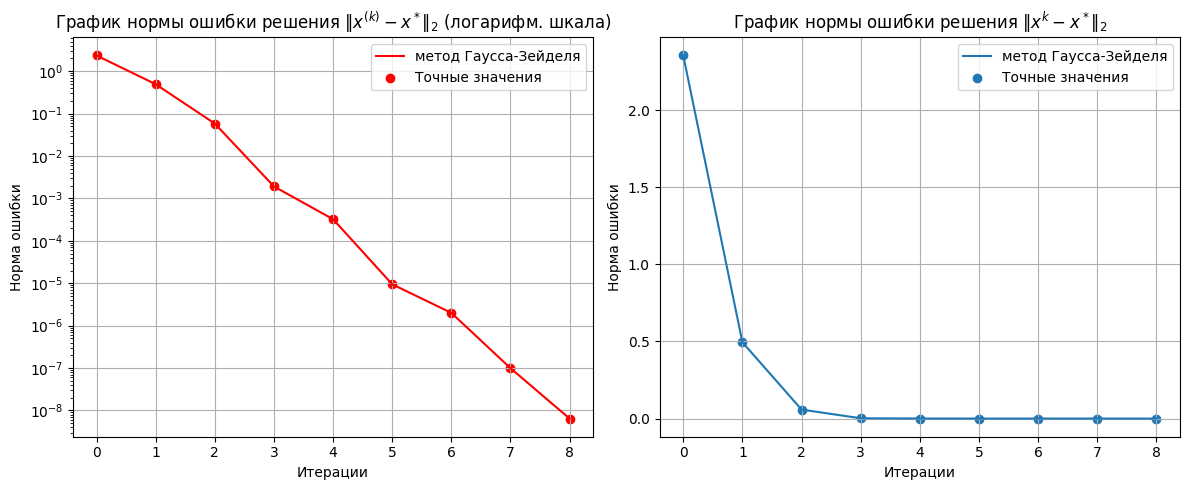

In [13]:
A = np.array([
    [10, 2, 1, 1, 0],
    [2, 11, 1, 0, 1],
    [1, 1, 10, 2, 1],
    [1, 0, 2, 11, 1],
    [0, 1, 1, 1, 10]
])
b = np.array([15, 13, 16, 17, 14])

iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000)
write_statistics(A, b, iter_x, iterations_amount, only_iter_and_eigenvals=True, method="метод Якоби")
x_k_vs_true_x(history, x_history, method="Метод Якоби")

iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000)
write_statistics(A, b, iter_x, iterations_amount, only_iter_and_eigenvals=True, method="метод Гаусса-Зейделя")
x_k_vs_true_x(history, x_history, method="Метод Гаусса-Зейделя")

### (b)  $x^{(0)}$ - случайный вектор, $\|x^{(0)}\|_2$ = 1

Начальное приближение x0: [ 0.5914308  -0.35844876  0.0654251  -0.03552377  0.71845787]

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 32

Максимальное по модулю собственное число матрицы B: 0.2642220939494057

Точное решение: [ 0.60147264 -1.10614855  1.78754165  1.87197678 -0.60507363]

Итерационное решение [ 0.60147264 -1.10614855  1.78754165  1.87197678 -0.60507363]

Разница итерационного и точного решений: [3.57111896e-10 8.99946340e-10 7.68106245e-10 8.02020006e-10
 5.99648775e-10]



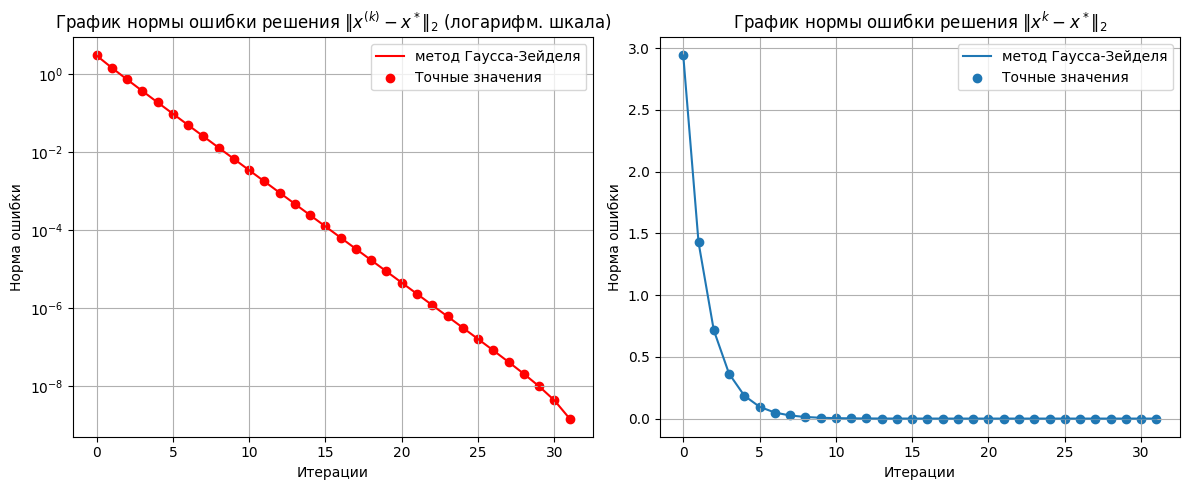

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 17

Максимальное по модулю собственное число матрицы B: 0.2642220939494057

Точное решение: [ 0.60147264 -1.10614855  1.78754165  1.87197678 -0.60507363]

Итерационное решение [ 0.60147264 -1.10614855  1.78754165  1.87197678 -0.60507363]

Разница итерационного и точного решений: [2.16170337e-09 4.70792294e-10 3.86772836e-11 5.88681992e-10
 6.33582076e-10]



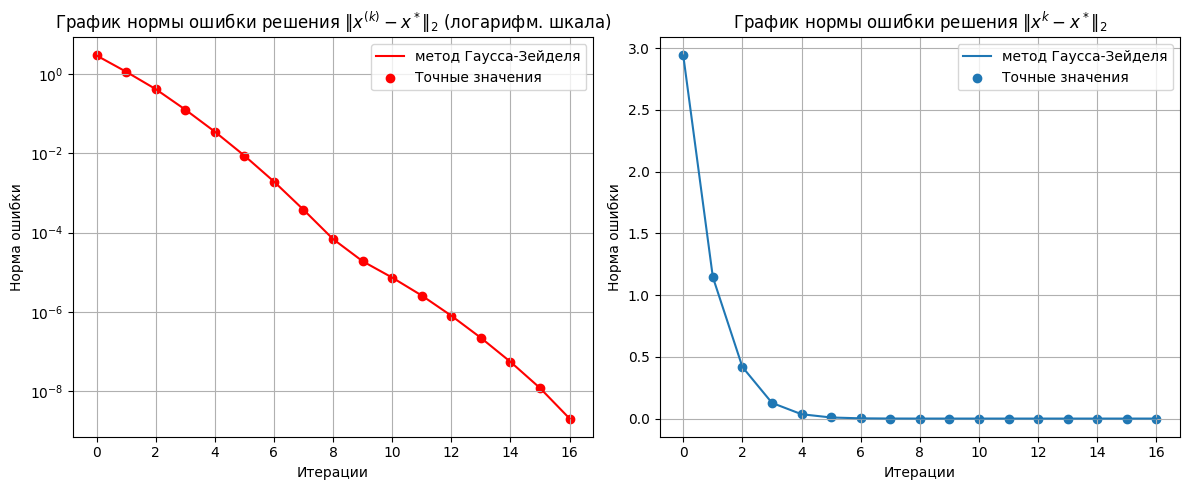

In [14]:
A = np.array([
    [7, -2, 1, 0, 2],
    [-2, 8, 2, 1, -1],
    [1, 2, 9, -1, 1],
    [0, 1, -1, 7, 2],
    [2, -1, 1, 2, 8]
])
b = np.array([7, -4, 12, 9, 3])
x0 = np.random.randn(5)
x0 /= np.linalg.norm(x0) # Нормируем вектор

print(r"Начальное приближение x0:", x0, end='\n\n')

iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000)
write_statistics(A, b, iter_x, iterations_amount, method="метод Якоби")
x_k_vs_true_x(history, x_history, method="метод Якоби")

iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000)
write_statistics(A, b, iter_x, iterations_amount, method="метод Гаусса-Зейделя")
x_k_vs_true_x(history, x_history, method="метод Гаусса-Зейделя")

### **(c)** $x^{(0)}$ близок к точному решению $x^{*}$.

Начальное приближение x0: [1.7650169  1.23377091 1.54336984 1.78018966 2.06969365]
-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 32

Максимальное по модулю собственное число матрицы B: 0.11126535564702227

Точное решение: [1.76160774 1.23566183 1.54159776 1.78418873 2.07052607]

Итерационное решение [1.76160774 1.23566183 1.54159776 1.78418873 2.07052606]

Разница итерационного и точного решений: [1.79309456e-10 1.93793204e-10 1.90187643e-10 1.54865232e-10
 8.70894468e-11]



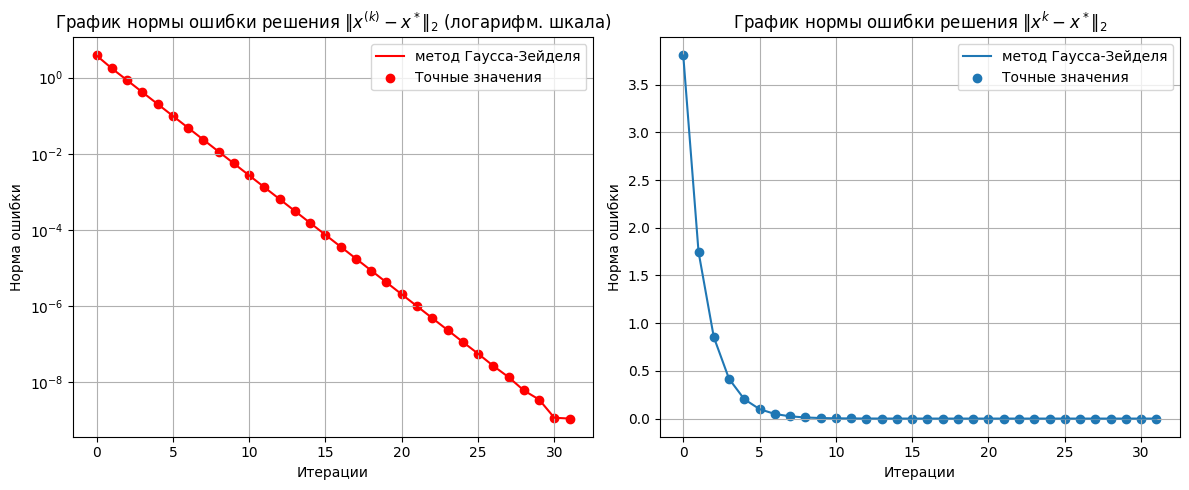

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 11

Максимальное по модулю собственное число матрицы B: 0.11126535564702227

Точное решение: [1.76160774 1.23566183 1.54159776 1.78418873 2.07052607]

Итерационное решение [1.76160774 1.23566183 1.54159776 1.78418873 2.07052607]

Разница итерационного и точного решений: [2.37518738e-09 1.06080478e-10 8.38694891e-10 3.59640762e-10
 1.40985890e-10]



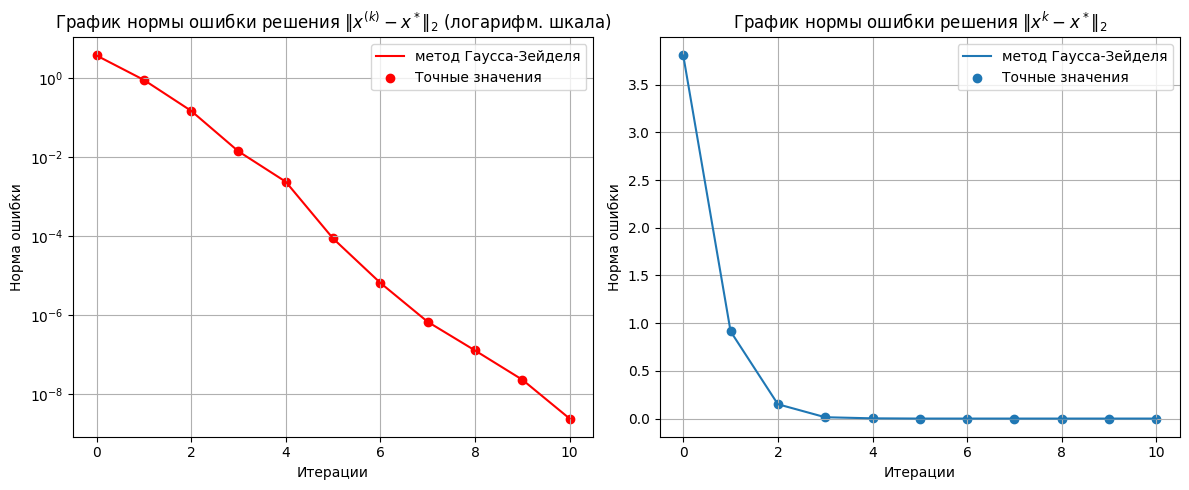

In [15]:
A = np.array([
    [12, 3, 2, 0, 1],
    [3, 13, 2, 2, 0],
    [2, 2, 14, 3, 1],
    [0, 2, 3, 15, 2],
    [1, 0, 1, 2, 16]
])
b = np.array([30, 28, 35, 38, 40])
true_x = np.linalg.solve(A, b)
x0 = true_x + 0.005 * np.random.randn(5)
print("Начальное приближение x0:", x0)

iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000)
write_statistics(A, b, iter_x, iterations_amount, method='метод Якоби')
x_k_vs_true_x(history, x_history, method='метод Якоби')


iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000)
write_statistics(A, b, iter_x, iterations_amount, method='метод Гаусса-Зейделя')
x_k_vs_true_x(history, x_history, method='метод Гаусса-Зейделя')